# vi.ve — Run the Generator 🎛️

Self-serve MIDI generation with the **established riding-trap engine** (trial-08 ruleset). No assistant needed: run the cells top to bottom, grade the manifest, load the verdicts.

**The loop:**
1. **Configure** — pick random exploration or a registered style's weights
2. **Generate** — MIDI lands in `~/Music/Ableton/User Library/vibes forever/`
3. **Grade** — fill the manifest's keep/ehh/cream + diagnostic columns
4. **Load** — verdicts go to Postgres; full-cream packs auto-register as styles

Engine rules baked in (from 8 trials of feedback): 808 frame with root at C3 · kick+bass locked per bar (morning/sicko pool only — the retired out-there structure can't occur) · bar-1 ceiling at C4 · bars end on root or b7 · loop lands on the root, bar 4 low · one-vocabulary melodies in the E4–E5 lane · best-of-6 candidate gate.

In [1]:
import sys, json, warnings
from pathlib import Path
sys.path.append(str(Path("../scripts").resolve()))

import numpy as np
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
import vive_engine as ve

warnings.filterwarnings("ignore", message=".*SQLAlchemy.*")
SONG_COLORS = {"morning": "#2a78d6", "out there": "#1baf7a", "sicko mode": "#eda100"}
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
BLUE = "#2a78d6"
sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "grid.color": GRID,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

conn = psycopg2.connect(dbname="vive", port=5431)
q = lambda sql: pd.read_sql(sql, conn)
print("connected — vive @ localhost:5431")

/Users/trell/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


connected — vive @ localhost:5431


## 1 · Configure the run

Two modes:
- **`random`** — fresh weighted dice each combo: explores new territory on the style map
- **`style`** — reruns a registered style's stored weights (new dice, same recipe)

Registered styles on file:

In [2]:
q("SELECT name, created, recipe->>'status' AS status, verdict FROM styles ORDER BY id")

,name,created,status,verdict
0,riding trap,2026-07-13,ESTABLISHED,ESTABLISHED 2026-07-13 after 8 trials (keep ar...
1,cream-t5-v01,2026-07-15,None,all 3 files cream
2,cream-t5-v03,2026-07-15,None,all 3 files cream
3,cream-t5-v04,2026-07-15,None,all 3 files cream
4,cream-t6-v05,2026-07-15,None,all 3 files cream


In [3]:
TRIAL = ve.next_trial_number()     # auto-numbers from the archived runs
MODE = "random"                    # "random" or "style"
STYLE_NAME = "riding trap"         # used when MODE == "style"
N_COMBOS = 8                       # packs to generate (each = melody + bassline + drums)

print(f"this run will be trial {TRIAL}  ·  mode: {MODE}  ·  {N_COMBOS} packs")

this run will be trial 9  ·  mode: random  ·  8 packs


## 2 · Generate

Each combo internally rolls **6 candidate packs** and only the best rubric score reaches your ears. `bass bar 1` and `lands on` are printed in Ableton note names (C3 = middle C = your 808 root) so you can sanity-check the lane before even loading a file.

In [4]:
if MODE == "style":
    combos = ve.combos_from_style(STYLE_NAME, n=N_COMBOS)
    manifest = ve.run_trial(TRIAL, combos=combos)
else:
    manifest = ve.run_trial(TRIAL, n_combos=N_COMBOS)

summary = pd.DataFrame([{
    "combo": m["id"], "label": m["label"], "key": m["key"], "bpm": m["bpm"],
    "melody vocab": m["melody_vocabulary"], "gate score": m["chosen_score"],
    "bass bar 1": " ".join(m["bass_bar1_notes"]), "lands on": m["bass_last_note"],
} for m in manifest])
print(f"{len(manifest) * 3} MIDI files written to  ~/Music/Ableton/User Library/vibes forever/")
summary

24 MIDI files written to  ~/Music/Ableton/User Library/vibes forever/


,combo,label,key,bpm,melody vocab,gate score,bass bar 1,lands on
0,v01,mor20 out37 sic42,Ebm,76.55,morning,9.0,B2 B2 B2 B2,Eb3
1,v02,mor57 out35 sic8,Em,75.78,out there,9.0,C3 C3 C3 C3,E3
2,v03,mor40 out11 sic49,Ebm,75.52,sicko mode,8.0,B2 B2 B2 B2,Eb3
3,v04,mor10 out66 sic24,Ebm,78.61,out there,9.0,Eb3 Eb3 Eb3 Eb3 Eb3 Eb3,Eb3
4,v05,mor45 out25 sic28,Em,74.77,out there,9.0,E3 E3 E3 E3 E3 E3,E3
5,v06,mor34 out34 sic32,Ebm,76.42,sicko mode,9.0,B2 B2 B2 B2,Eb3
6,v07,mor45 out13 sic42,Em,75.27,sicko mode,9.0,E3 E3 E3 E3 E3 E3,E3
7,v08,mor14 out45 sic41,Ebm,77.88,morning,9.0,B2 B2 B2 B2,Eb3


## 3 · How output lands in the database

Nothing from this run is in Postgres *yet* — the database only stores **graded** results (your verdicts are the training signal, not the generation itself). Three tables carry the system:

**`metrics`** — the long-format analysis mart built from your hand-played packs (the DNA the generator samples from):

In [5]:
q("""SELECT song, scope, metric, value_num FROM metrics
     WHERE metric IN ('ktb_co_hit_rate','space_ratio') AND song <> 'ALL'
     ORDER BY metric, song LIMIT 8""")

,song,scope,metric,value_num
0,morning,kick|bassline,ktb_co_hit_rate,0.9500
1,out there,kick|chorus bassline,ktb_co_hit_rate,1.0000
2,out there,kick|verse bassline,ktb_co_hit_rate,0.6400
3,sicko mode,kick|bassline,ktb_co_hit_rate,1.0000
4,morning,snare,space_ratio,0.9701
5,morning,clap,space_ratio,0.9505
6,morning,kick,space_ratio,0.8887
7,morning,hihat,space_ratio,0.6966


**`trial_results`** — every verdict you've ever marked, one row per file per trial (this is what turns your taste into rules):

In [6]:
q("""SELECT trial,
            count(*) FILTER (WHERE keep AND file_kind <> 'pack')  AS kept,
            count(*) FILTER (WHERE cream AND file_kind <> 'pack') AS cream,
            count(*) FILTER (WHERE file_kind <> 'pack')           AS files
     FROM trial_results GROUP BY trial ORDER BY trial""")

,trial,kept,cream,files
0,1,0,0,24
1,2,11,0,24
2,3,17,0,24
3,4,19,0,24
4,5,24,18,24
5,6,17,16,24


**`styles`** — named, recreatable formulas. Only cream-worthy formulas live here; full-cream packs auto-register on load:

In [7]:
print(q("SELECT jsonb_pretty(recipe->'ruleset') AS rules FROM styles WHERE name = 'riding trap'").rules[0])

{
    "frame": "808 audio sample, root at middle C = C3 = MIDI 60 (Ableton naming)",
    "melody": "one song's whole vocabulary (winner by weight), AA'BA motif, lead lane E4-E5, barline pickups",
    "bar_endings": "root, or b7 when the bar opens on the root; never an octave below root",
    "bar1_ceiling": "most of bar 1 never a full octave+ above middle C",
    "loop_landing": "final note = root at the 808 octave; bar 4 is the loop's low point",
    "candidate_gate": "6 candidates per combo, best rubric score presented (generate_vibes_v8.score_pack)",
    "excluded_source": "out there verse bassline — the retired +8/octave/octave/+5 structure",
    "bass_source_pool": [
        "morning",
        "sicko mode"
    ],
    "kick_bass_locked": "each bar's kick+bass come from the same song (anchor rule)"
}


## 4 · The math inside this run

**The candidate gate.** Every pack you'll hear beat 5 siblings on the rubric (808 lane +2 · loop-ends-low +2 · bounce +1 · bar-1 ceiling +1 · root landing +1 · kick↔bass lock +3 · melody density +1 · tight register +1 · retired structure **−3**). Gray dots = discarded candidates, colored = what you got:

/Users/trell/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/trell/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/trell/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/trell/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated 

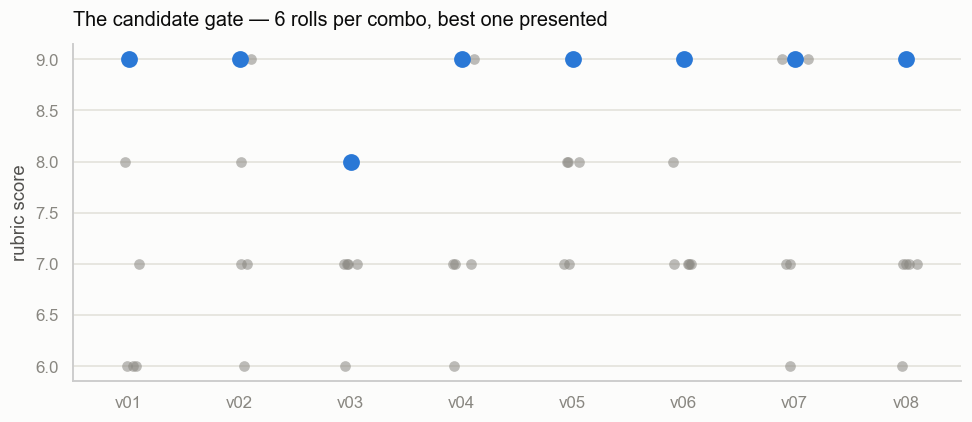

In [8]:
rows = []
for m in manifest:
    for j, s in enumerate(m["candidate_scores"]):
        rows.append({"combo": m["id"], "score": s,
                     "status": "presented" if s == m["chosen_score"] and j == m["candidate_scores"].index(m["chosen_score"]) else "discarded"})
cand = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 4))
sns.stripplot(data=cand[cand.status == "discarded"], x="combo", y="score",
              color=MUTED, alpha=0.55, size=7, jitter=0.12, ax=ax)
sns.stripplot(data=cand[cand.status == "presented"], x="combo", y="score",
              color=BLUE, size=11, jitter=False, ax=ax)
ax.set_title("The candidate gate — 6 rolls per combo, best one presented",
             loc="left", fontsize=13, pad=12)
ax.set_xlabel(""); ax.set_ylabel("rubric score")
plt.tight_layout(); plt.show()

**Why sources must be curated, not just weighted.** The trial-7 post-mortem lesson: with per-bar weighted dice, a source appears in a 4-bar pattern with probability `1-(1-w)⁴`. Even a *small* weight nearly guarantees its DNA shows up — which is why a disliked structure has to be removed from the pool, not down-weighted:

/var/folders/4b/ltxykyrn7j9bt96tg5cjy76h0000gn/T/ipykernel_50941/873896094.py:12: UserWarning: Glyph 8308 (\N{SUPERSCRIPT FOUR}) missing from current font.
  plt.tight_layout(); plt.show()
/Users/trell/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8308 (\N{SUPERSCRIPT FOUR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


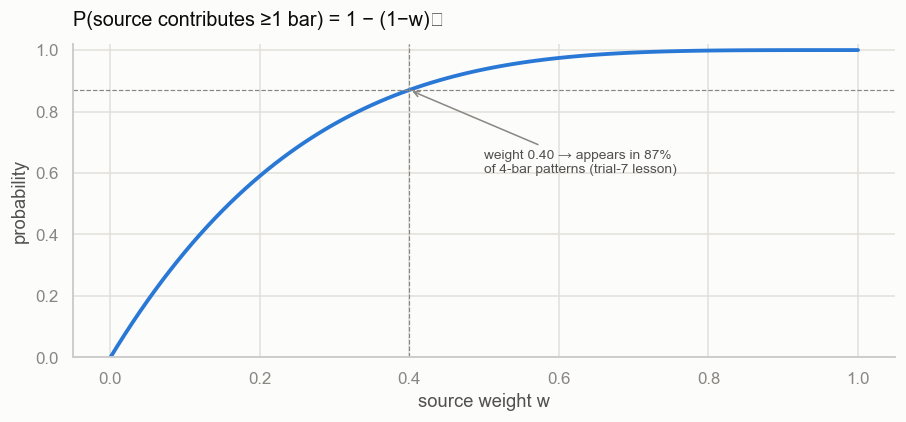

In [9]:
w = np.linspace(0, 1, 101)
fig, ax = plt.subplots(figsize=(8.4, 4))
ax.plot(w, 1 - (1 - w) ** 4, color=BLUE, lw=2.5)
ax.axhline(0.87, color=MUTED, lw=0.8, ls="--")
ax.axvline(0.4, color=MUTED, lw=0.8, ls="--")
ax.annotate("weight 0.40 → appears in 87%\nof 4-bar patterns (trial-7 lesson)",
            xy=(0.4, 0.87), xytext=(0.5, 0.6), fontsize=9, color=INK2,
            arrowprops=dict(arrowstyle="->", color=MUTED))
ax.set_title("P(source contributes ≥1 bar) = 1 − (1−w)⁴", loc="left", fontsize=13, pad=12)
ax.set_xlabel("source weight w"); ax.set_ylabel("probability")
ax.set_ylim(0, 1.02)
plt.tight_layout(); plt.show()

## 5 · Grade it, then load the verdicts

The manifest is at **`~/Music/Ableton/User Library/vibes forever/manifest.csv`** — same v2 questionnaire as always: `keep` / `ehh` / `cream` tiers, diagnostic flags (each maps to a generator knob), and the WHOLE PACK row for `gels` / `rides` / `song worthy`. Cream implies keep; blank diagnostics mean "no comment."

When you're done grading, run the cell below (it archives your filled manifest and loads it — **full-cream packs auto-register in `styles`** for you to rename):

In [10]:
RUN_AFTER_GRADING = False   # flip to True once manifest.csv is filled out

if RUN_AFTER_GRADING:
    import shutil, subprocess
    filled = Path.home() / "Music/Ableton/User Library/vibes forever/manifest.csv"
    archive = Path(f"../data/trial_{TRIAL:02}_manifest_filled.csv").resolve()
    shutil.copy(filled, archive)
    r = subprocess.run([sys.executable, "../scripts/load_trial_results.py", str(TRIAL),
                        str(archive), "--run-manifest",
                        str(Path(f"../data/generation_run_trial_{TRIAL:02}.json").resolve())],
                       capture_output=True, text=True)
    print(r.stdout or r.stderr)
else:
    print(f"grade the manifest first, then set RUN_AFTER_GRADING = True and re-run this cell (trial {TRIAL})")

grade the manifest first, then set RUN_AFTER_GRADING = True and re-run this cell (trial 9)


---
*Engine: `scripts/vive_engine.py` — the seed of the future `vive` package. Roadmap: package → ask-for-what-you-want generation → AI assistant producer bot; waveform analysis for mixing and audio-sample-to-MIDI further out.*